决策边界方程: -11.74 + 1.53*x1 + 3.11*x2 = 0


C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ZhuanZ（无密码）\AppData\Roaming\Python\Python314\site-packa

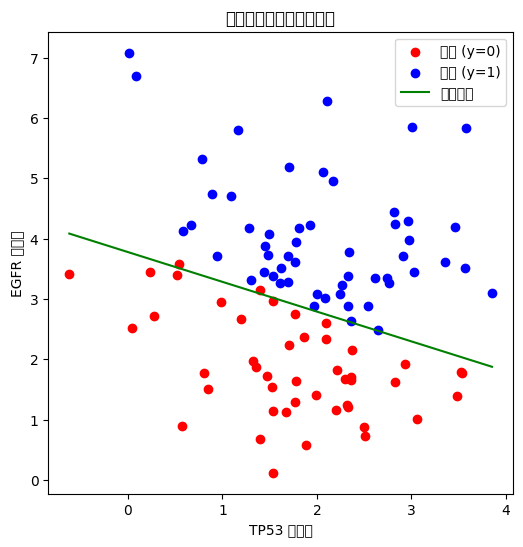

代价函数值 (Log Loss): 0.1409


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# 1. 构建模拟数据集
np.random.seed(42)
n_samples = 100

# 随机生成两个基因表达量
x1 = np.random.normal(loc=2.0, scale=1.0, size=n_samples)   # TP53
x2 = np.random.normal(loc=3.0, scale=1.5, size=n_samples)   # EGFR

# 标签：人为设定一个分界规则
y = (0.8*x1 + 1.2*x2 - 5 > 0).astype(int)

X = np.column_stack((x1, x2))

# 2. 训练逻辑回归模型
model = LogisticRegression()
model.fit(X, y)

# 3. 决策边界方程
theta0 = model.intercept_[0]
theta1, theta2 = model.coef_[0]
print("决策边界方程: {:.2f} + {:.2f}*x1 + {:.2f}*x2 = 0".format(theta0, theta1, theta2))

# 4. 可视化数据点和决策边界
plt.figure(figsize=(6,6))
plt.scatter(x1[y==0], x2[y==0], color='red', label='耐药 (y=0)')
plt.scatter(x1[y==1], x2[y==1], color='blue', label='敏感 (y=1)')

# 决策边界直线
x1_range = np.linspace(min(x1), max(x1), 100)
x2_boundary = -(theta0 + theta1*x1_range)/theta2
plt.plot(x1_range, x2_boundary, color='green', label='决策边界')

plt.xlabel("TP53 表达量")
plt.ylabel("EGFR 表达量")
plt.legend()
plt.title("逻辑回归决策边界示意图")
plt.show()

# 5. 计算代价函数值
y_pred_prob = model.predict_proba(X)[:,1]
cost = log_loss(y, y_pred_prob)
print("代价函数值 (Log Loss): {:.4f}".format(cost))


In [ ]:
# 1. 构建模拟数据集
np.random.seed(42)
n_samples = 100

# 随机生成两个基因表达量
x1 = np.random.normal(loc=2.0, scale=1.0, size=n_samples)   # TP53
x2 = np.random.normal(loc=3.0, scale=1.5, size=n_samples)   # EGFR